**Importanto bibliotecas necessárias**

In [1]:
# Pandas - manipulação e análise dos dados
import pandas as pd

# Numpy - processamento matricial
import numpy as np

# Matplotlib pyplot - API de plotagem
import matplotlib as mpl
from matplotlib import pyplot as plt

# Seaborn
import seaborn as sns

#Altair - biblioteca de visualização baseada no Vega
import altair as alt
alt.renderers.enable ()

# Definindo alinhamento e tamanho das figuras plotadas
plt.rcParams["figure.figsize"]=[8,5]

# **1. Preparando dados**

Subindo dados da aula anterior já preparados, sem remoção de extremos

In [2]:
from google.colab import files
uploaded_files = files.upload()

Saving dataset_limpo.csv to dataset_limpo.csv


In [5]:
df = pd.read_csv('dataset_limpo.csv', sep=",")
df.head()

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
0,Lucas Souza,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,1400.00,0.0,0.0,0.0,0.00,0.0,1400.00
1,Daniela Santos,SD 1C PM,POLICIA MILITAR SAO PAULO,5571.16,4249.8,0.0,0.0,1152.60,0.0,7385.42
2,Gabriel Santos,CAP PM,POLICIA MILITAR SAO PAULO,17445.85,0.0,0.0,0.0,307.36,0.0,8013.77
3,Eduardo Oliveira,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,5481.27,0.0,0.0,0.0,0.00,0.0,3855.71
4,Mariana Rodrigues,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,7791.00,0.0,0.0,0.0,0.00,0.0,5953.34


Verificando dados:

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
remuneração_do_mês,494243.0,7307.823259,5833.737103,0.00,4271.575,6465.62,8490.94,226729.46
férias_e_13º_salário,494243.0,538.763526,1962.160589,-15455.39,0.000,0.00,0.00,125399.69
pagamentos_eventuais,494243.0,319.345670,2855.937860,-82683.35,0.000,0.00,0.00,200013.02
licença_prêmio_indenizada,494243.0,65.502028,903.573040,-3967.44,0.000,0.00,0.00,46366.18
abono_permanência_&_outras_indenizações,494243.0,519.853048,2461.879692,-55557.50,0.000,0.00,499.46,286850.36
redutor_salarial,494243.0,-57.002827,1485.288131,-192715.71,0.000,0.00,0.00,0.00
total_liquído_r$,494243.0,5919.614917,6210.785189,-74083.35,3172.150,4791.14,6656.91,336099.30


Precisamos separar os dados numéricos dos dados não numéricos:

In [7]:
features = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

dados = df[features]
meta = df[['nome', 'cargo', 'orgão']]

# **2. Analisando a estrutura de dependência das variáveis**

Vamos primeiro entender como as variáveis se relacionam.

Até agora, nós olhamos cada variável de forma isolada.
Mas os dados não funcionam assim no mundo real — eles acontecem juntos.

Então a pergunta agora é:

como essas variáveis interagem entre si?

---

O correlograma nos dá uma visão geral dessas relações.

Ele mostra:

* quais variáveis caminham juntas
* quais são independentes
* e quais podem estar explicando umas às outras

Mas cuidado…

*Correlação não é causalidade.*

Ela indica associação, não explica o motivo.

---

Agora, além do correlograma, vamos olhar os scatter plots.

Esse gráficos são úteis para se entender o comportamento das relações dos dados, demonstrada por suas variáveis. Eles demosntram dentro da relação de depentência o que pode estar ocorrendo.

---

Com os scatter plots, conseguimos identificar:

* padrões
* agrupamentos
* dispersões
* e principalmente… pontos que fogem do padrão

---

Nesse ponto podemos começar a refinar nossas hipóteses e nosso entendimento sobre o dataset.

Porque esses pontos que fogem do padrão?

- erro?
- podem ser eventos
- ou podem ser exatamente o que queremos investigar

---

Então, enquanto vocês olham os gráficos, eu quero que pensem:

- quais variáveis parecem estar conectadas?

- existe algum padrão claro?

- ou o sistema é mais complexo do que parece?

---

Porque é a partir dessas relações…

que melhoraremos o entendimento da estrutura dos dados.


# 2.1. Correlograma

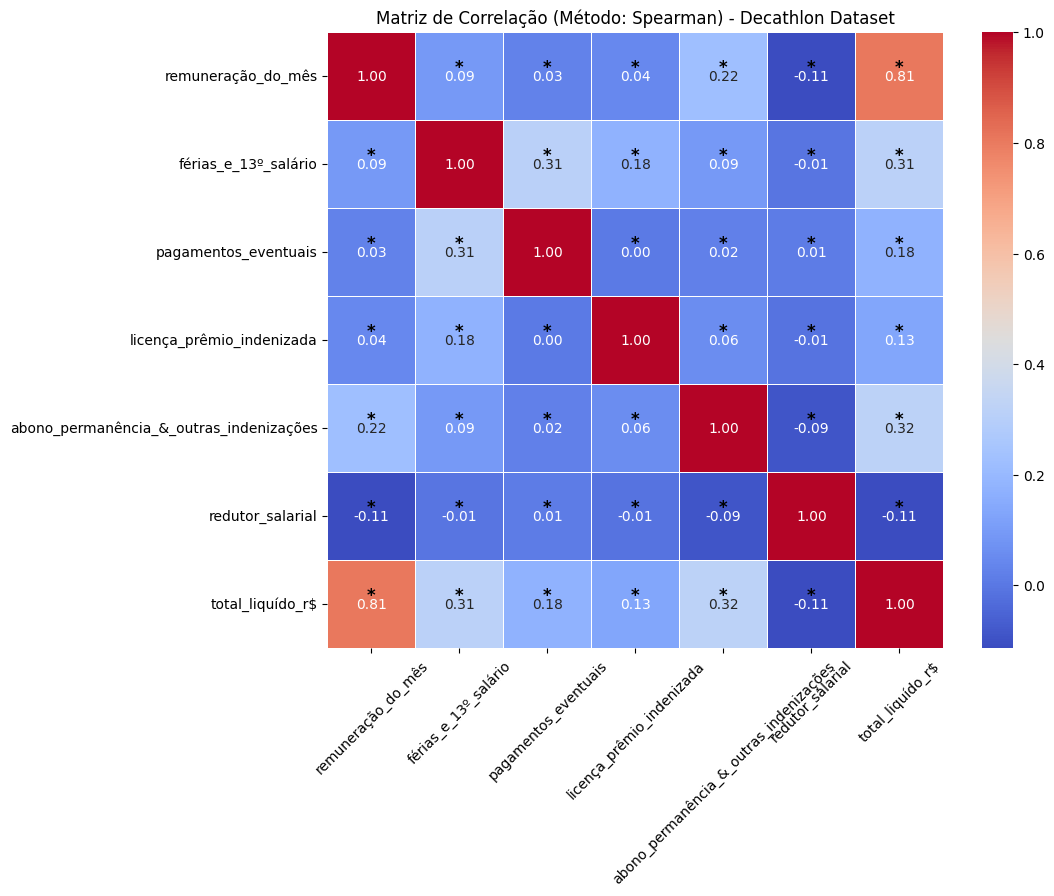

In [13]:
# Correlograma (correlações)

from scipy.stats import pearsonr, spearmanr, kendalltau

# Função para calcular os p-valores das correlações
def calculate_p_values(dados, method='spearman'):
    if method == 'pearson':
        corr_func = pearsonr
    elif method == 'spearman':
        corr_func = spearmanr
    elif method == 'kendall':
        corr_func = kendalltau
    else:
        raise ValueError("Método de correlação não reconhecido. Use 'pearson', 'spearman' ou 'kendall'.")

    num_features = dados.shape[1]
    p_values = np.ones((num_features, num_features))

    for i in range(num_features):
        for j in range(i + 1, num_features):
            corr, p_value = corr_func(dados.iloc[:, i], dados.iloc[:, j])
            p_values[i, j] = p_value
            p_values[j, i] = p_value

    return p_values


# Escolha o método de correlação (pearson, spearman, kendall)
method = 'spearman'

# Calcular a matriz de correlação
correlation_matrix = dados.corr(method=method)

# Calcular os p-valores das correlações
p_values = calculate_p_values(dados, method=method)

# Plotar o heatmap da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10},
            cbar=True, square=True, linewidths=0.5, linecolor='white')
plt.title(f'Matriz de Correlação (Método: {method.capitalize()}) - Decathlon Dataset')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Adicionar asterisco nas células com p-value < 0.05 para indicar significância
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        if p_values[i, j] < 0.05:
            plt.text(j + 0.5, i + 0.5, "*", ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')

plt.show()

# 2.2. Scatter plots

Esse códiogo irá construir Scatter plots com todos os dados (quase meio milhão de registros), isso tomará muito tempo, pois iremos plotar todos os dados do dataset, sempre par a par (entre duas variáveis).

In [ ]:
# Correlograma (Scatterplots) - Plotando todos os dados
sns.pairplot(dados, kind="scatter", plot_kws=dict(s=80, edgecolor="white", linewidth=2.5))
plt.show()

Para otimizar nosso tempo, podemos rodar o Scatter plot com uma amostra grande do dataset, isso já nos permitirá identificar padrões e estruturas que estão ocultas as análise univariadas.

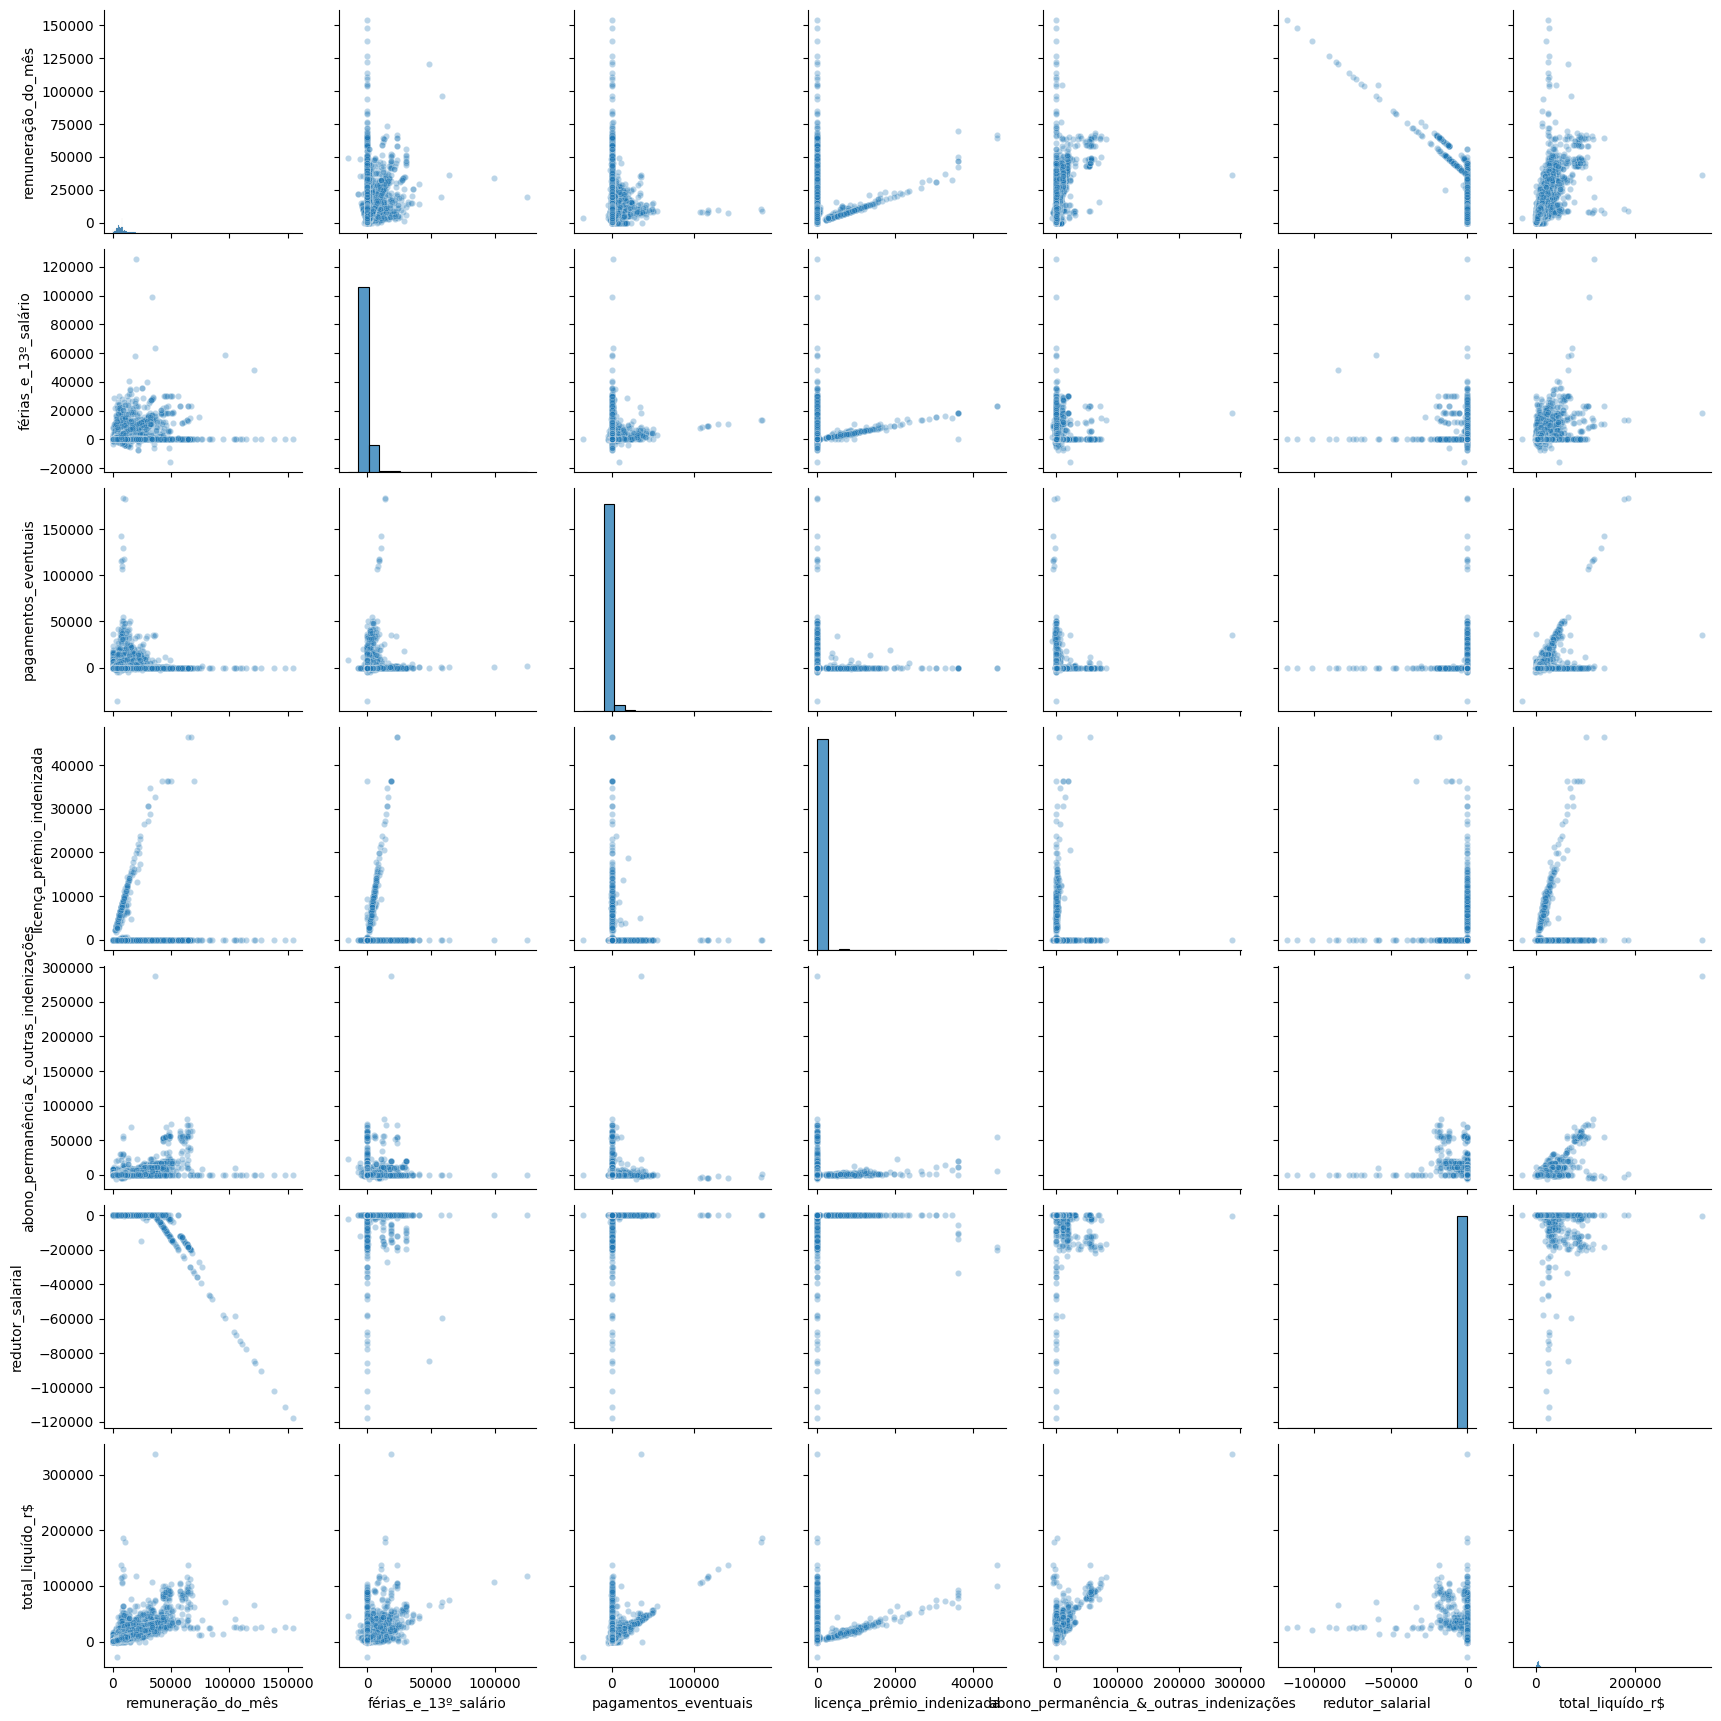

In [ ]:
# Correlograma (Scatter plots) - Plotando uma amostra
import seaborn as sns
import matplotlib.pyplot as plt

sample = dados.sample(n=50000, random_state=42)

sns.pairplot(sample, kind="scatter",
             plot_kws=dict(s=20, alpha=0.3))

plt.show()

# **3. PCA**

A PCA realiza a determinação de autovalores e autovetores através da matriz de covariância dos dados. Essa operação é denominada "decomposição espectral", oriunda da Algebra Linear.

Caso deseje conhecer mais sobre, eu encontrei um exemplo, onde o Autor realizou a PCA passo a passo: https://leandrocruvinel.medium.com/pca-na-m%C3%A3o-e-no-python-d559e9c8f053

A matriz de covariância é definida apenas para variáveis numéricas, sejam elas discretas ou contínuas.

Aplicam-se aqui princípios semelhantes aos discutidos anteriormente para a correlação, porém com foco na variabilidade conjunta dos dados. De forma sintética, a covariância expressa como a variação de uma variável está associada à variação de outra. Valores positivos indicam que as variáveis tendem a variar no mesmo sentido, enquanto valores negativos indicam variação em sentidos opostos.

Entretanto, a covariância é diretamente influenciada pela magnitude das variáveis. Como a variância depende da escala dos dados, variáveis com maior amplitude tendem a exercer maior influência na análise.

Por essa razão, é fundamental realizar o escalonamento das variáveis antes da aplicação da Análise de Componentes Principais (PCA), garantindo que todas contribuam de forma equilibrada para a construção dos componentes.


**Etapa importante!!! Separando os dados númericos e escalonando**

Etapa importante: separação das variáveis numéricas e escalonamento dos dados.

Para a aplicação de técnicas como a Análise de Componentes Principais (PCA), é necessário trabalhar exclusivamente com variáveis numéricas, uma vez que os cálculos envolvidos — como variância e covariância — não são definidos para dados categóricos.

Assim, o primeiro passo consiste em selecionar apenas as variáveis numéricas do conjunto de dados, garantindo que a análise seja matematicamente consistente.

Em seguida, realiza-se o escalonamento dessas variáveis. Esse procedimento é fundamental, pois coloca todas as variáveis em uma mesma escala, eliminando o efeito da magnitude dos valores. Sem essa etapa, variáveis com maior amplitude poderiam dominar a análise, influenciando de forma desproporcional os resultados.

Dessa forma, o escalonamento assegura que cada variável contribua de maneira equilibrada para a construção dos componentes principais, permitindo uma interpretação mais adequada da estrutura dos dados.


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(dados)

df_scaled = pd.DataFrame(scaled_data)
print("Dados escalonados:")
df_scaled.head()

Dados escalonados:


,0,1,2,3,4,5,6
0,-1.012701,-0.274577,-0.111818,-0.072492,-0.211161,0.038378,-0.727705
1,-0.297693,1.891303,-0.111818,-0.072492,0.257018,0.038378,0.236010
2,1.737829,-0.274577,-0.111818,-0.072492,-0.086313,0.038378,0.337181
3,-0.313102,-0.274577,-0.111818,-0.072492,-0.211161,0.038378,-0.332310
4,0.082825,-0.274577,-0.111818,-0.072492,-0.211161,0.038378,0.005430


Nós precisamos dos nomes das colunas para que apareçam na PCA, vamos reatribuir ao df escalonado

In [16]:
# Salvando os nomes das variáveis e o índice original
nomes_variaveis = dados.columns.tolist()
indice_original = dados.index.tolist()

# Criando um novo DataFrame com os dados escalonados
df_scaled = pd.DataFrame(scaled_data, columns=nomes_variaveis, index=indice_original)
print("Dados escalonados:")
df_scaled.head()

Dados escalonados:


,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
0,-1.012701,-0.274577,-0.111818,-0.072492,-0.211161,0.038378,-0.727705
1,-0.297693,1.891303,-0.111818,-0.072492,0.257018,0.038378,0.236010
2,1.737829,-0.274577,-0.111818,-0.072492,-0.086313,0.038378,0.337181
3,-0.313102,-0.274577,-0.111818,-0.072492,-0.211161,0.038378,-0.332310
4,0.082825,-0.274577,-0.111818,-0.072492,-0.211161,0.038378,0.005430


Vamos ver como mudou numericamente a partir da estatística descritiva. Consegue ver a diferença?

In [17]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
remuneração_do_mês,494243.0,-3.325545e-16,1.000001,-1.252684,-0.520464,-0.144368,0.202806,37.612572
férias_e_13º_salário,494243.0,3.624287e-17,1.000001,-8.151305,-0.274577,-0.274577,-0.274577,63.634472
pagamentos_eventuais,494243.0,-1.013535e-17,1.000001,-29.063230,-0.111818,-0.111818,-0.111818,69.922346
licença_prêmio_indenizada,494243.0,1.460641e-17,1.000001,-4.463332,-0.072492,-0.072492,-0.072492,51.241817
abono_permanência_&_outras_indenizações,494243.0,-4.998669e-17,1.000001,-22.778290,-0.211161,-0.211161,-0.008284,116.305763
redutor_salarial,494243.0,1.207616e-18,1.000001,-129.711467,0.038378,0.038378,0.038378,0.038378
total_liquído_r$,494243.0,-1.545174e-16,1.000001,-12.881309,-0.442370,-0.181696,0.118712,53.162363


# **3.1. Realizando a PCA**

Na biblioteca scikit-learn, os métodos *fit()*, *transform()* e *fit_transform()* desempenham papéis fundamentais no ajuste e na aplicação de modelos aos dados.

O método *fit()* é utilizado para ajustar o modelo aos dados, ou seja, para estimar seus parâmetros a partir do conjunto de entrada. No caso da Análise de Componentes Principais (PCA), o *fit()* calcula as direções de maior variância (componentes principais) com base nos dados fornecidos, sem ainda realizar qualquer transformação sobre eles. Trata-se, portanto, da etapa de aprendizado do modelo.

O método *transform()*, por sua vez, aplica aos dados a transformação previamente aprendida. No contexto do PCA, isso significa projetar os dados no novo espaço definido pelos componentes principais, reexpressando as variáveis originais em termos dessas novas dimensões e eliminando, assim, a redundância associada à correlação entre variáveis.

Já o método *fit_transform()* combina ambas as etapas em uma única operação: primeiro ajusta o modelo aos dados e, em seguida, realiza a transformação. Por essa razão, é frequentemente utilizado na prática, pois torna o processo mais direto e eficiente, especialmente quando não há necessidade de separar explicitamente as etapas de ajuste e transformação.


# 3.1.1. Realizando a PCA e analisando a variância explicada pelas PCs geradas

In [22]:
from sklearn.decomposition import PCA

# Especificando o número de componentes principais desejados
num_componentes_desejados = 7  # Defina o número desejado de componentes principais aqui (o número de componentes não poderá ser superior ao número de colunas numéricas)

# Realizando a PCA para os dados escalonados
pca = PCA(n_components=num_componentes_desejados).fit(df_scaled)

# Obtendo as variâncias explicadas
variancia_explicada = pca.explained_variance_

# Normalizando as variâncias para que somem 100%
variancia_explicada_percentual = variancia_explicada / np.sum(variancia_explicada) * 100

print("Número de componentes principais Obtidos:")
print(num_componentes_desejados)
print()

print("Variância explicada (valor absoluto):")
print(variancia_explicada)
print()

print("Variância explicada (%):")
print(variancia_explicada_percentual)
print()


Número de componentes principais Obtidos:
7

Variância explicada (valor absoluto):
[2.6710402  1.24406711 1.02977307 0.79837193 0.75698681 0.47033349
 0.02944154]

Variância explicada (%):
[38.1576399  17.77235138 14.71101416 11.40529026 10.81407548  6.71903631
  0.42059251]



1. Visualizando variância explicada graficamente

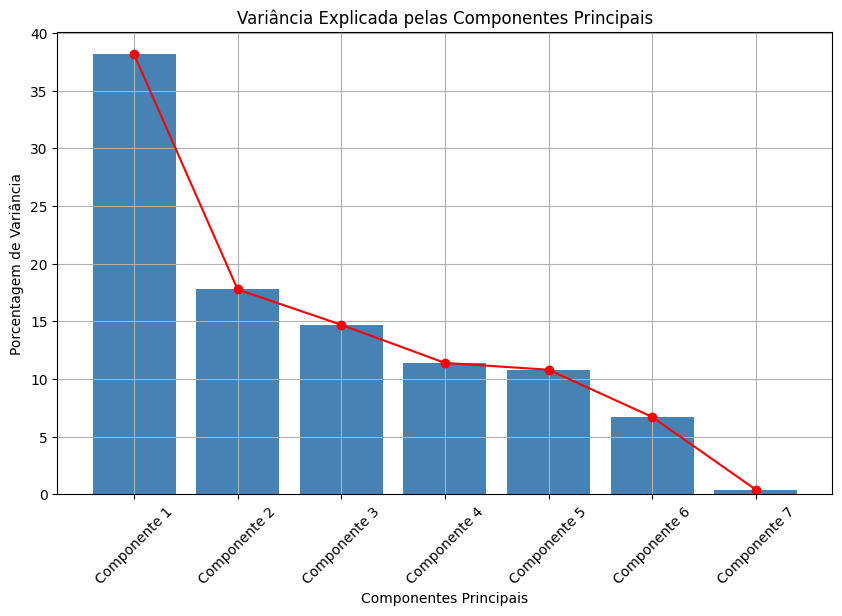

In [23]:
# Dando nome as componentes
nomes_componentes = ["Componente " + str(i+1) for i in range(num_componentes_desejados)]

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(np.arange(num_componentes_desejados) + 1, variancia_explicada_percentual, color='steelblue')
plt.xticks(np.arange(num_componentes_desejados) + 1, nomes_componentes, rotation=45)
plt.xlabel('Componentes Principais')
plt.ylabel('Porcentagem de Variância')
plt.title('Variância Explicada pelas Componentes Principais')
plt.grid(True)

# Adicionar linhas conectando os pontos
plt.plot(np.arange(num_componentes_desejados) + 1, variancia_explicada_percentual, marker='o', linestyle='-', color='red')

plt.show()

2. Visualizando autovalores para aplicação do critério de Kaiser (autovalor maior do que 1)

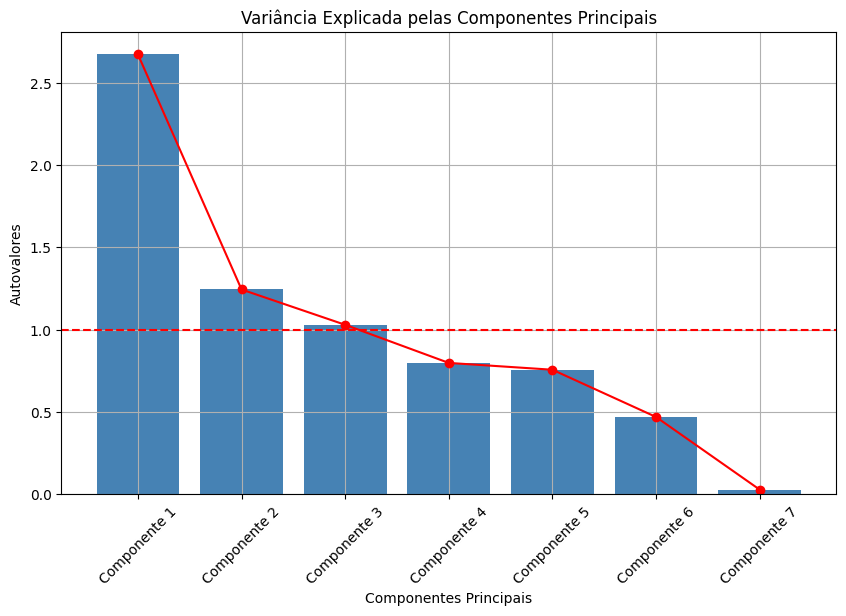

In [24]:
# Obtendo os autovalores (variâncias explicadas)
autovalores = pca.explained_variance_

# Dando nome as componentes
nomes_componentes = ["Componente " + str(i+1) for i in range(num_componentes_desejados)]

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(np.arange(num_componentes_desejados) + 1, autovalores, color='steelblue')
plt.xticks(np.arange(num_componentes_desejados) + 1, nomes_componentes, rotation=45)
plt.xlabel('Componentes Principais')
plt.ylabel('Autovalores')
plt.title('Variância Explicada pelas Componentes Principais')
plt.grid(True)

# Adicionar linhas conectando os pontos
plt.plot(np.arange(num_componentes_desejados) + 1, autovalores, marker='o', linestyle='-', color='red')

# Adicionando a linha tracejada vermelha no valor 1 do eixo y
plt.axhline(y=1, color='red', linestyle='--')

plt.show()

In [26]:
#valores dos autovalores
print("Autovalores:")
print(autovalores)
print()
print("Nota algo similar em relação ao valor absoluto da variância explicada? \nTemos sete variáveis, mas só três dimensões são realmente relevantes.")

Autovalores:
[2.6710402  1.24406711 1.02977307 0.79837193 0.75698681 0.47033349
 0.02944154]

Nota algo similar em relação ao valor absoluto da variância explicada? 
Temos sete variáveis, mas só três dimensões são realmente relevantes.


3. Examinando as componentes principais de interesse

In [27]:
# Definindo as PCs desejadas que você quer examinar
pcs_desejadas = [0, 1, 2]  # Substitua com as PCs que deseja examinar

# Obtendo os autovalores (loadings) das componentes principais
explained_variance = pca.explained_variance_[pcs_desejadas]

# Obtendo os autovetores (loadings) das componentes principais
loadings = pca.components_[pcs_desejadas, :].T

df_coord = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in pcs_desejadas],
    index=nomes_variaveis
)

print(df_coord)

                                              PC1       PC2       PC3
remuneração_do_mês                       0.499294 -0.283804 -0.005968
férias_e_13º_salário                     0.293151  0.419340  0.278484
pagamentos_eventuais                     0.194167  0.518286 -0.651487
licença_prêmio_indenizada                0.167750  0.360913  0.694566
abono_permanência_&_outras_indenizações  0.427296 -0.251893 -0.011700
redutor_salarial                        -0.284267  0.497394 -0.024175
total_liquído_r$                         0.579256  0.184064 -0.121789


**Sobre as coordenadas das variáveis**:

Na Análise de Componentes Principais (PCA), as coordenadas das variáveis representam os pesos associados a cada variável na formação dos componentes principais. Em outras palavras, indicam como cada variável contribui para a construção de cada componente.

A PCA transforma o conjunto original de variáveis em novas dimensões — os componentes principais — que são combinações lineares das variáveis originais. Cada componente é construído de forma a capturar uma parcela da variabilidade total dos dados.

As coordenadas das variáveis permitem interpretar essas novas dimensões. O sinal da coordenada indica a direção da relação com o componente (positiva ou negativa), enquanto o seu valor absoluto indica a intensidade dessa contribuição.

Assim, variáveis com coordenadas de maior magnitude exercem maior influência na definição do componente principal. Por outro lado, valores próximos de zero indicam baixa contribuição.

Dessa forma, a análise das coordenadas é fundamental para compreender quais variáveis estão estruturando cada componente e, consequentemente, para interpretar o comportamento geral do conjunto de dados.


In [28]:
import numpy as np
import pandas as pd

# PCs que você quer analisar
pcs_desejadas = [0, 1, 2]

# Variância explicada (autovalores)
explained_variance = pca.explained_variance_[pcs_desejadas]

# Loadings (autovetores) → formato (variáveis x PCs)
loadings = pca.components_[pcs_desejadas, :].T

# -----------------------------
# CONTRIBUIÇÃO DAS VARIÁVEIS
# -----------------------------

# contribuição = loading² * autovalor
contrib = (loadings ** 2) * explained_variance

# normaliza por componente (soma = 1 em cada PC)
contrib = contrib / contrib.sum(axis=0)

# DataFrame
df_contrib = pd.DataFrame(
    contrib,
    columns=[f'PC{i+1}' for i in pcs_desejadas],
    index=nomes_variaveis
)

print("Contribuição das variáveis:")
print(df_contrib)

Contribuição das variáveis:
                                              PC1       PC2       PC3
remuneração_do_mês                       0.249294  0.080545  0.000036
férias_e_13º_salário                     0.085937  0.175846  0.077553
pagamentos_eventuais                     0.037701  0.268620  0.424435
licença_prêmio_indenizada                0.028140  0.130258  0.482422
abono_permanência_&_outras_indenizações  0.182582  0.063450  0.000137
redutor_salarial                         0.080808  0.247401  0.000584
total_liquído_r$                         0.335538  0.033879  0.014833


**Sobre a contribuição das variáveis:**

A contribuição das variáveis na Análise de Componentes Principais (PCA) indica o quanto cada variável participa da formação de um determinado componente principal.

Enquanto as coordenadas mostram a direção e a intensidade da relação entre a variável e o componente, a contribuição quantifica a importância relativa de cada variável dentro desse componente.

Em termos práticos, a contribuição permite identificar quais variáveis são mais relevantes para explicar a variabilidade capturada por cada componente principal. Para cada componente, a soma das contribuições das variáveis é igual a 100%, o que possibilita comparar diretamente a importância relativa entre elas.

Assim, variáveis com maiores valores de contribuição são aquelas que mais influenciam a definição do componente, enquanto variáveis com baixa contribuição têm participação limitada na sua formação.

A análise das contribuições complementa a interpretação das coordenadas, permitindo compreender não apenas a direção das relações, mas também o peso efetivo de cada variável na estrutura dos dados.


3. Factor loadings

In [ ]:
import numpy as np

factor_loadings = pca.components_[pcs_desejadas, :].T * np.sqrt(explained_variance)

df_loadings = pd.DataFrame(
    factor_loadings,
    columns=[f'PC{i+1}' for i in pcs_desejadas],
    index=nomes_variaveis
)

print(df_loadings)

                                              PC1       PC2       PC3
remuneração_do_mês                       0.816011 -0.316549 -0.006056
férias_e_13º_salário                     0.479106  0.467722  0.282599
pagamentos_eventuais                     0.317334  0.578085 -0.661114
licença_prêmio_indenizada                0.274160  0.402554  0.704830
abono_permanência_&_outras_indenizações  0.698343 -0.280956 -0.011873
redutor_salarial                        -0.464587  0.554782 -0.024532
total_liquído_r$                         0.946697  0.205301 -0.123589


**Sobre os factor loadings:**

Os *factor loadings* representam uma forma ajustada das coordenadas das variáveis nos componentes principais, incorporando a variância explicada por cada componente. Eles podem ser interpretados como uma medida da relação entre as variáveis originais e os componentes principais.

Enquanto as coordenadas indicam a direção e o peso relativo das variáveis, os *factor loadings* refletem de maneira mais direta a intensidade dessa associação, considerando também a importância de cada componente na explicação da variabilidade dos dados.

Em termos práticos, os *factor loadings* podem ser interpretados de forma semelhante a coeficientes de correlação entre as variáveis originais e os componentes principais. Assim, valores mais elevados em magnitude indicam uma relação mais forte, enquanto valores próximos de zero indicam baixa associação.

Dessa forma, a análise dos *factor loadings* permite compreender com maior precisão como cada variável se relaciona com os componentes principais, complementando a interpretação obtida a partir das coordenadas e das contribuições.

Em conjunto, essas três medidas — coordenadas, contribuição e *factor loadings* — oferecem uma visão completa da estrutura dos dados no espaço reduzido gerado pela PCA.


**Conclusão da interpretação da PCA**

A aplicação da Análise de Componentes Principais (PCA) permitiu identificar padrões estruturais relevantes no conjunto de dados, que não eram evidentes na análise univariada.

Os resultados indicam que o primeiro componente principal (PC1) está fortemente associado à magnitude geral da remuneração, sendo influenciado principalmente pelas variáveis relacionadas ao valor total recebido. Essa dimensão pode ser interpretada como um eixo de volume financeiro.

O segundo componente principal (PC2), por sua vez, evidencia diferenças na composição da remuneração, destacando o papel de variáveis como pagamentos eventuais, benefícios e redutores. Essa dimensão revela variações estruturais no sistema, indicando que valores semelhantes de remuneração podem ser formados por combinações distintas de componentes.

A análise conjunta das contribuições e dos *factor loadings* permite compreender não apenas quais variáveis estão mais associadas a cada componente, mas também o quanto elas influenciam sua formação. Essa abordagem é fundamental para evitar interpretações simplistas, especialmente em sistemas com alta variabilidade e presença de valores extremos.

É importante destacar que a PCA não fornece explicações causais, mas sim uma reorganização do espaço de dados, evidenciando padrões e relações latentes. Dessa forma, sua interpretação deve ser realizada de maneira crítica e sempre contextualizada com o conhecimento do domínio.

Por fim, observa-se que diferentes componentes capturam diferentes aspectos do sistema: enquanto alguns refletem a magnitude dos valores, outros revelam a estrutura interna dos dados. Essa distinção é essencial para orientar análises posteriores, como a identificação de anomalias e a escolha de modelos mais adequados para o problema em questão.


# 3.1.2. Biplot

Agora vamos visualizar um fenômeno multidimensional em um gráfico de duas dimensões

1. Preparando os dados

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PREPARAÇÃO
# =========================

features = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

# Scores completos (não plotar tudo!)
scores = pca.transform(df[features])

# Factor loadings (mais interpretáveis)
loadings = pca.components_.T[:, :2] * np.sqrt(pca.explained_variance_[:2])

2. Visualizando os vetores (variáveis) no biplot

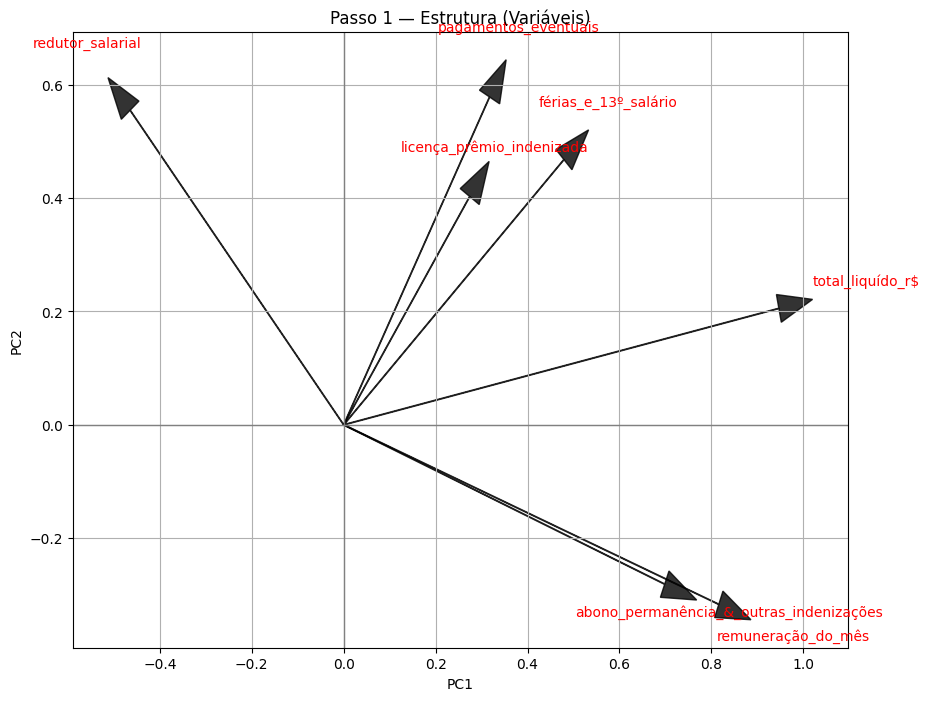

In [36]:
# =========================
# PASSO 1 — VETORES
# =========================

plt.figure(figsize=(10, 8))

for i, var_name in enumerate(features):
    plt.arrow(0, 0,
              loadings[i, 0],
              loadings[i, 1],
              color='black',
              alpha=0.8,
              head_width=0.05)

    plt.text(loadings[i, 0]*1.2,
             loadings[i, 1]*1.2,
             var_name,
             color='red',
             ha='center')

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.title('Passo 1 — Estrutura (Variáveis)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.show()

3. Agora vemos como os dados se organizam nesse espaço

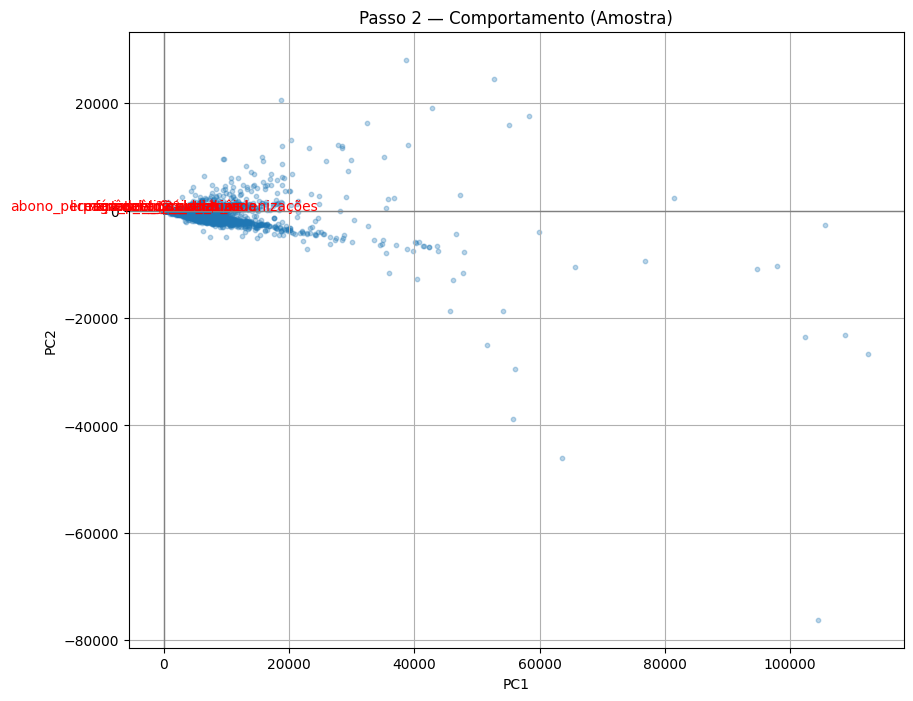

In [37]:
# =========================
# PASSO 2 — AMOSTRA
# =========================

sample = df.sample(n=3000, random_state=42)
scores_sample = pca.transform(sample[features])

plt.figure(figsize=(10, 8))

# pontos
plt.scatter(scores_sample[:, 0], scores_sample[:, 1],
            alpha=0.3, s=10)

# vetores
for i, var_name in enumerate(features):
    plt.arrow(0, 0,
              loadings[i, 0],
              loadings[i, 1],
              color='black',
              alpha=0.8,
              head_width=0.05)

    plt.text(loadings[i, 0]*1.2,
             loadings[i, 1]*1.2,
             var_name,
             color='red',
             ha='center')

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.title('Passo 2 — Comportamento (Amostra)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.show()


4. E aqui… quem foge do padrão

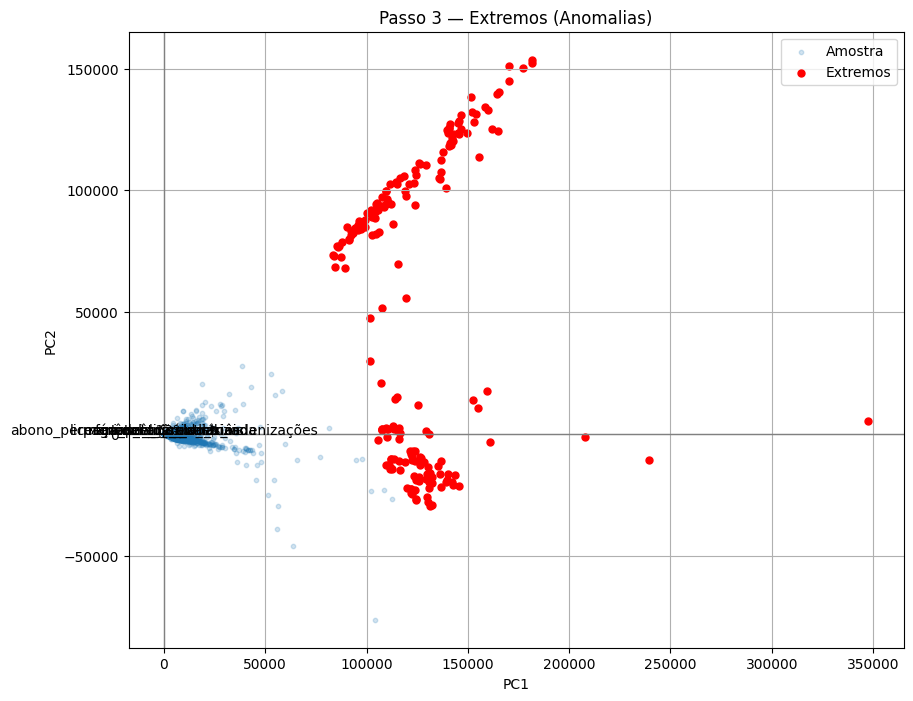

In [38]:
# =========================
# PASSO 3 — EXTREMOS
# =========================

# Top salários (você pode trocar critério)
extremos = df.nlargest(200, 'total_liquído_r$')
scores_extremos = pca.transform(extremos[features])

plt.figure(figsize=(10, 8))

# amostra
plt.scatter(scores_sample[:, 0], scores_sample[:, 1],
            alpha=0.2, s=10, label='Amostra')

# extremos
plt.scatter(scores_extremos[:, 0], scores_extremos[:, 1],
            color='red', s=25, label='Extremos')

# vetores
for i, var_name in enumerate(features):
    plt.arrow(0, 0,
              loadings[i, 0],
              loadings[i, 1],
              color='black',
              alpha=0.8,
              head_width=0.05)

    plt.text(loadings[i, 0]*1.2,
             loadings[i, 1]*1.2,
             var_name,
             color='black',
             ha='center')

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.legend()
plt.title('Passo 3 — Extremos (Anomalias)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.show()

Quem são esses pontos?

In [ ]:
extremos.head()

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
179743,Eduardo Pereira,AUDITOR FISCAL DA RECEITA EST,SECRET. FAZENDA PLANEJAMENTO,36445.81,18150.76,35468.00,0.0,286850.36,-144.28,336099.30
350001,Carlos Rodrigues,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,8992.27,27939.28,195382.23,0.0,0.00,0.00,226292.18
315524,Juliana Oliveira,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,9119.25,26391.16,200013.02,0.0,0.00,0.00,225245.46
368447,Daniela Oliveira,DELEGADO POLICIA 1A CLASSE,SECRETARIA SEGURANCA PUBLICA,38306.64,8488.44,14280.67,0.0,200776.44,-2005.11,221750.63
192979,Carlos Almeida,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,8450.80,27125.17,194927.60,0.0,0.00,0.00,219193.35


***Será que a análise seria igual sem os outliers?***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. REMOVER OUTLIERS (IQR)
# =========================

Q1 = df_scaled.quantile(0.25)
Q3 = df_scaled.quantile(0.75)
IQR = Q3 - Q1

mask = ~((df_scaled < (Q1 - 1.5 * IQR)) |
         (df_scaled > (Q3 + 1.5 * IQR))).any(axis=1)

df_scaled_clean = df_scaled[mask].copy()

print("Original:", df_scaled.shape)
print("Sem outliers:", df_scaled_clean.shape)

# =========================
# 2. PCA (RECOMENDADO REAJUSTAR)
# =========================

from sklearn.decomposition import PCA

pca_clean = PCA(n_components=2)
scores_clean = pca_clean.fit_transform(df_scaled_clean)

# factor loadings (mais interpretáveis)
loadings_clean = pca_clean.components_.T * np.sqrt(pca_clean.explained_variance_)

# =========================
# 3. AMOSTRAGEM
# =========================

idx_sample = np.random.choice(len(scores_clean), size=3000, replace=False)
scores_sample = scores_clean[idx_sample]


Original: (494243, 7)
Sem outliers: (311987, 7)


Biplot

Sem amostras

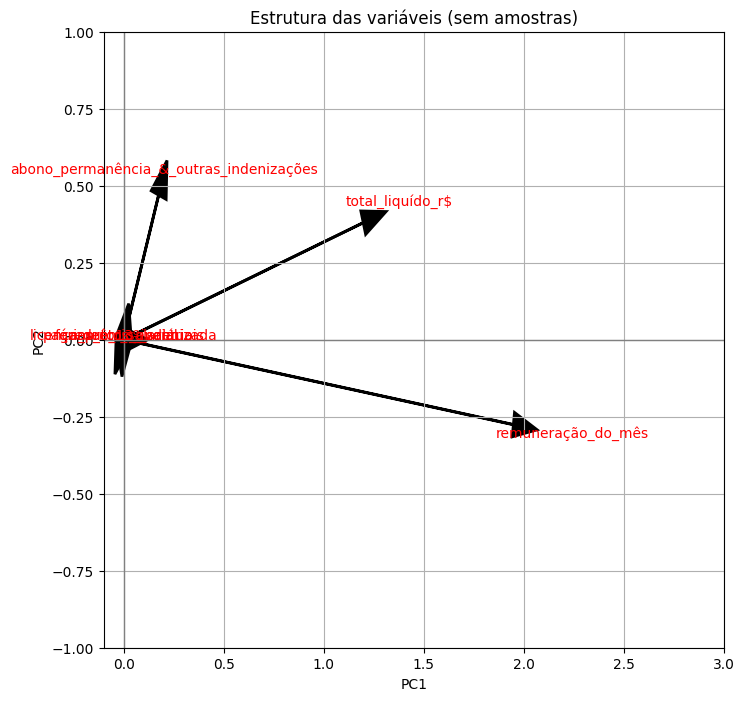

In [ ]:
# =========================
# BIPLOT SEM AMOSTRAS
# =========================

plt.figure(figsize=(8, 8))

# escala maior (agora pode aumentar mais)
scale = 4

for i, var_name in enumerate(df_scaled_clean.columns):
    x = loadings_clean[i, 0] * scale
    y = loadings_clean[i, 1] * scale

    plt.arrow(0, 0,
              x, y,
              color='black',
              alpha=1,
              linewidth=2,
              head_width=0.08)

    plt.text(x*1.15,
             y*1.15,
             var_name,
             color='red',
             ha='center')

# eixos centrais
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

# escala simétrica (importante aqui)
plt.xlim(-scale, scale)
plt.ylim(-scale, scale)

# labels
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Estrutura das variáveis (sem amostras)')
plt.grid()

plt.xlim(-0.1, 3)
plt.ylim(-1, 1)

plt.show()

Visualizando as amostras

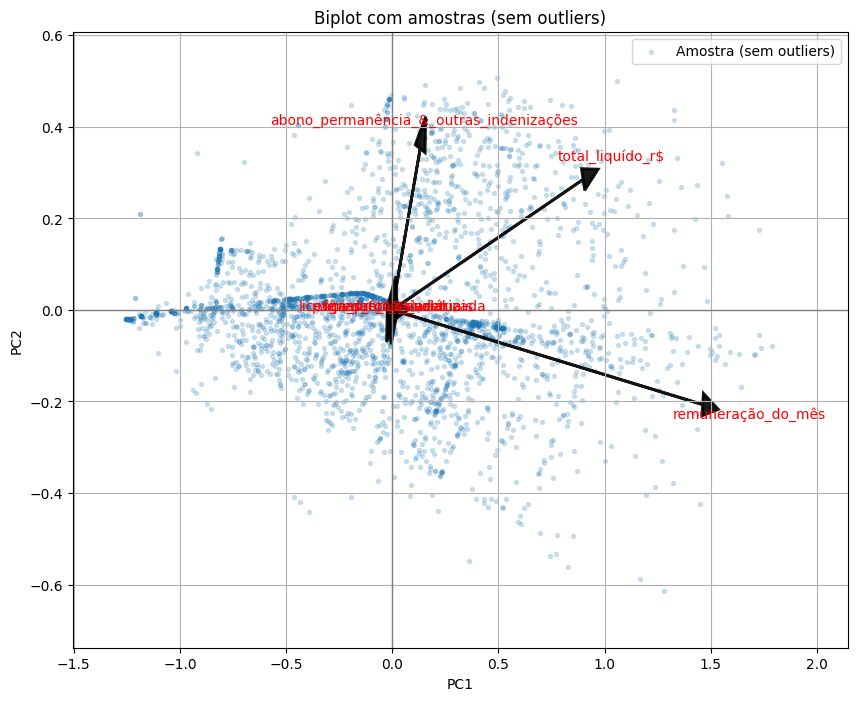

In [ ]:
# =========================
# 4. BIPLOT COM AMOSTRAS
# =========================

plt.figure(figsize=(10, 8))

# -------------------------
# PONTOS (AMOSTRAS)
# -------------------------
plt.scatter(scores_sample[:, 0], scores_sample[:, 1],
            alpha=0.2, s=8, label='Amostra (sem outliers)')

# -------------------------
# VETORES (ESCALADOS)
# -------------------------
scale = 3  # aumenta visibilidade

for i, var_name in enumerate(df_scaled_clean.columns):
    x = loadings_clean[i, 0] * scale
    y = loadings_clean[i, 1] * scale

    plt.arrow(0, 0,
              x, y,
              color='black',
              alpha=0.9,
              linewidth=2,
              head_width=0.05)

    plt.text(x*1.15,
             y*1.15,
             var_name,
             color='red',
             ha='center')

# -------------------------
# EIXOS CENTRAIS
# -------------------------
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

# -------------------------
# AJUSTE DE ESCALA (IMPORTANTE)
# -------------------------
all_x = np.concatenate([scores_sample[:, 0], loadings_clean[:, 0]*scale])
all_y = np.concatenate([scores_sample[:, 1], loadings_clean[:, 1]*scale])

plt.xlim(all_x.min()*1.2, all_x.max()*1.2)
plt.ylim(all_y.min()*1.2, all_y.max()*1.2)

# -------------------------
# LABELS
# -------------------------
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot com amostras (sem outliers)')
plt.legend()
plt.grid()

plt.show()

# **4. Aprofundando: PCA com rotação**

A rotação na Análise de Componentes Principais (PCA) é um procedimento que visa melhorar a interpretação dos componentes principais, facilitando a identificação e a compreensão das relações entre as variáveis originais e os componentes.

A necessidade de rotação surge porque os componentes principais extraídos pela PCA podem ser dificilmente interpretáveis devido à natureza ortogonal dos componentes. Isso significa que os componentes são independentes entre si, mas podem não representar claramente as relações complexas entre as variáveis originais. A rotação busca simplificar essas relações, tornando os componentes mais interpretáveis.

Existem diferentes métodos de rotação disponíveis, cada um com suas próprias suposições e objetivos. Alguns dos métodos de rotação mais comuns incluem:

Varimax: Este é o método mais popular e amplamente utilizado. Ele visa maximizar a variância dos quadrados dos coeficientes de carga dentro de cada componente, o que resulta em componentes mais nítidos e esparsos.

Quartimax: Este método visa maximizar a variância dos quadrados dos coeficientes de carga em todas as variáveis para cada componente, o que resulta em componentes que explicam a maior parte da variância total.

Equamax: Este método é uma combinação do Varimax e do Quartimax. Ele busca uma solução intermediária entre a interpretabilidade dos componentes (Varimax) e a explicação da variância total (Quartimax).

Oblimin: Este método é adequado para casos em que se espera que os componentes estejam correlacionados. Ele permite a rotação de fatores em direção a fatores não ortogonais, o que pode ser mais realista em muitas situações do mundo real.

Promax: Este é um método de rotação promax, que é uma extensão do método Oblimin. Ele é especialmente útil quando se espera que os fatores sejam correlacionados, mas também quando se deseja simplificar a estrutura de fatores, permitindo que alguns fatores não estejam correlacionados.

In [39]:
import matplotlib.pyplot as plt
!pip install factor_analyzer
from sklearn.decomposition import PCA
from factor_analyzer import Rotator

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=9dfbe3b40428bfea5f722dc033da5a48948c78cddee5f9361432b3d83982daea
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


Sobre a função rotator (): https://factor-analyzer.readthedocs.io/en/latest/factor_analyzer.html#factor_analyzer.rotator.Rotator

In [40]:
# Aplicando a PCA para redução de dimensionalidade
pca = PCA(n_components=3)  # Reduzindo para 3 componentes principais (PC1, PC2 e PC3)
principal_components = pca.fit_transform(df_scaled)  # df_scaled é seu DataFrame escalonado

# Realizando a rotação Obliqua
rotator = Rotator(method='oblimin', max_iter=3)
rotated_components = rotator.fit_transform(principal_components)

# Criando um DataFrame pandas com os componentes rotacionados
df_rotated_components = pd.DataFrame(rotated_components, columns=[f'Rotated_PC{i+1}' for i in range(rotated_components.shape[1])], index=df_scaled.index)

print(df_rotated_components)

        Rotated_PC1  Rotated_PC2  Rotated_PC3
0         73.234234  -198.890197   125.435615
1       -216.018741   214.928838     0.779475
2         55.875633    92.892350  -148.595675
3         59.233222  -111.564394    52.238440
4         43.108940   -48.731415     5.628743
...             ...          ...          ...
494238    62.763050  -141.167698    78.271005
494239    49.368157   -97.838156    48.406417
494240  -140.447527   109.254394    30.973913
494241    62.618082   -42.997224   -19.626395
494242    56.564418   -62.195116     5.603888

[494243 rows x 3 columns]


Efeito da rotação

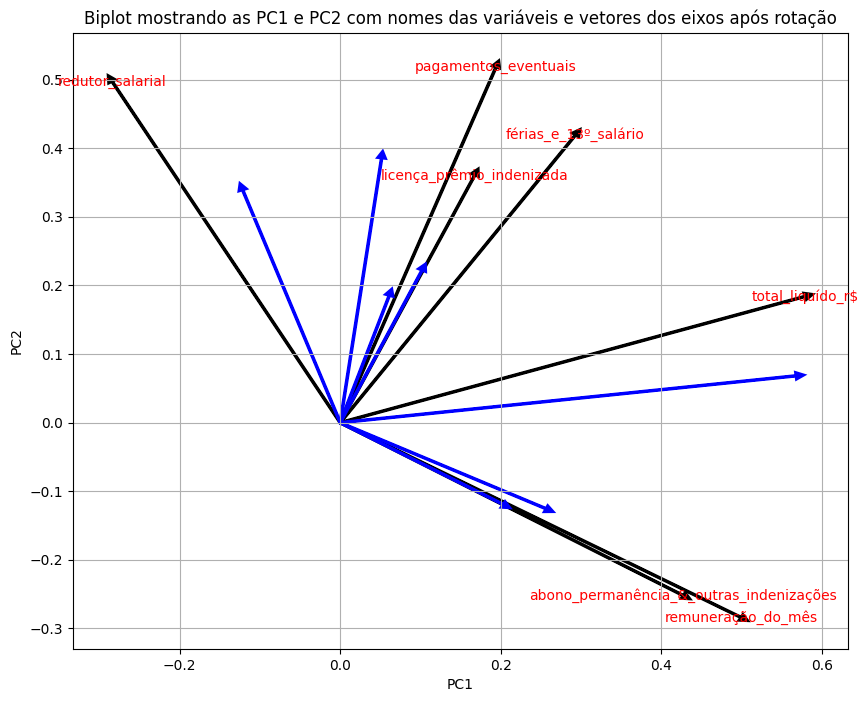

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from factor_analyzer import Rotator
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Aplicando a PCA para redução de dimensionalidade
pca = PCA(n_components=2)  # Reduzindo para 2 componentes principais (PC1, PC2)
principal_components = pca.fit_transform(df_scaled)

# Coordenadas das variáveis nas duas primeiras PCs
x = pca.components_[0]  # PC1
y = pca.components_[1]  # PC2

# Criando o biplot
plt.figure(figsize=(10, 8))
for i, var_name in enumerate(df_scaled.columns):
    plt.text(x[i], y[i], var_name, color='r', ha='center', va='center')
for i in range(pca.components_.shape[1]):
    plt.arrow(0, 0, pca.components_[0, i], pca.components_[1, i], color='k', linewidth=2,
              head_width=0.01, head_length=0.01)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()

# Aplicando a rotação Oblimin
rotator = Rotator(method='oblimin', max_iter=3)
rotated_components = rotator.fit_transform(pca.components_)

# Coordenadas das variáveis nas duas primeiras PCs após a rotação
x_rotated = rotated_components[0]  # PC1
y_rotated = rotated_components[1]  # PC2

# Desenhando os vetores dos eixos após a rotação
for i in range(rotated_components.shape[1]):
    plt.arrow(0, 0, rotated_components[0, i], rotated_components[1, i], color='b', linewidth=2,
              head_width=0.01, head_length=0.01)

# Exibindo o biplot
plt.title('Biplot mostrando as PC1 e PC2 com nomes das variáveis e vetores dos eixos após rotação')
plt.show()

Verificando a disposição das variáveis (altere o valor do paramentro max_iter para ver a rotação ocorrendo)

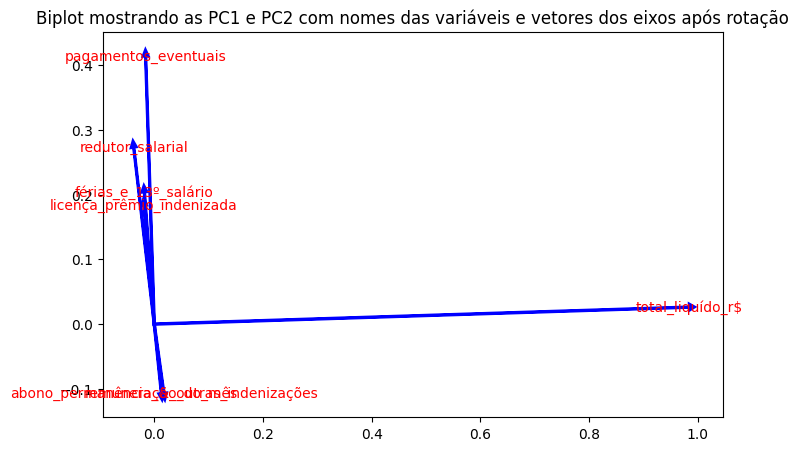

In [42]:
# Aplicando a rotação Oblimin
rotator = Rotator(method='oblimin', max_iter=10)
rotated_components = rotator.fit_transform(pca.components_)

# Coordenadas das variáveis nas duas primeiras PCs após a rotação
x_rotated = rotated_components[0]  # PC1
y_rotated = rotated_components[1]  # PC2

# Desenhando os vetores dos eixos após a rotação
for i, var_name in enumerate(df_scaled.columns):
    plt.text(x_rotated[i], y_rotated[i], var_name, color='r', ha='center', va='center')
for i in range(rotated_components.shape[1]):
    plt.arrow(0, 0, rotated_components[0, i], rotated_components[1, i], color='b', linewidth=2,
              head_width=0.01, head_length=0.01)

# Exibindo o biplot
plt.title('Biplot mostrando as PC1 e PC2 com nomes das variáveis e vetores dos eixos após rotação')
plt.show()

# **5. Aprofundando: PCA Utilizando Factor Analyzer (modo avançado)**

In [43]:
!pip install factor_analyzer

Loadings rotacionados

In [44]:
from factor_analyzer import FactorAnalyzer

#Componentes principais com rotação oblimin
fa = FactorAnalyzer(rotation="oblimin", n_factors=3, method='principal')
fa.fit(df_scaled)

#Obtenção das cargas fatoriais (loadings)
loadings2 = pd.DataFrame(fa.loadings_, index=df_scaled.columns, columns=[f"Fator{i+1}" for i in range(3)])

#Exibir os resultados
loadings2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Fator1,Fator2,Fator3
remuneração_do_mês,0.877607,-0.023714,0.008312
férias_e_13º_salário,0.106756,0.211619,0.628346
pagamentos_eventuais,-0.040170,0.949437,-0.094301
licença_prêmio_indenizada,-0.051710,-0.191563,0.872389
abono_permanência_&_outras_indenizações,0.757475,-0.022066,-0.004293
redutor_salarial,-0.722477,0.285220,0.200222
total_liquído_r$,0.681896,0.442595,0.264373


Cos2 rotacionados

In [52]:
# Ajustar o factor analyzer com os componentes principais e a rotação oblimin
fa = FactorAnalyzer(rotation="oblimin", n_factors=3, method='principal')
fa.fit(df_scaled)

# Obter as cargas fatoriais (loadings) após a rotação
loadings = fa.loadings_

# Calcular o cos² das variáveis para cada componente principal
cos2_variaveis = (loadings ** 2)

# Calcular as contribuições das variáveis para cada componente principal
contribuicoes_variaveis = (loadings ** 2) * fa.get_factor_variance()[0]

# Criar DataFrames pandas para as informações
df_coord = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(loadings.shape[1])], index=df_scaled.columns)
df_cos2 = pd.DataFrame(cos2_variaveis, columns=[f'PC{i+1}' for i in range(cos2_variaveis.shape[1])], index=df_scaled.columns)
df_contrib = pd.DataFrame(contribuicoes_variaveis, columns=[f'PC{i+1}' for i in range(contribuicoes_variaveis.shape[1])], index=df_scaled.columns)

# Exibir as primeiras linhas dos DataFrames
print("Coordenadas das variáveis:")
print(df_coord)
print("\nCos²:")
print(df_cos2)
print("\nContribuições para os componentes principais:")
print(df_contrib)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Coordenadas das variáveis:
                                              PC1       PC2       PC3
remuneração_do_mês                       0.877607 -0.023714  0.008312
férias_e_13º_salário                     0.106756  0.211619  0.628346
pagamentos_eventuais                    -0.040170  0.949437 -0.094301
licença_prêmio_indenizada               -0.051710 -0.191563  0.872389
abono_permanência_&_outras_indenizações  0.757475 -0.022066 -0.004293
redutor_salarial                        -0.722477  0.285220  0.200222
total_liquído_r$                         0.681896  0.442595  0.264373

Cos²:
                                              PC1       PC2       PC3
remuneração_do_mês                       0.770193  0.000562  0.000069
férias_e_13º_salário                     0.011397  0.044783  0.394819
pagamentos_eventuais                     0.001614  0.901430  0.008893
licença_prêmio_indenizada                0.002674  0.036696  0.761062
abono_permanência_&_outras_indenizações  0.573768  0.000

Biplot

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


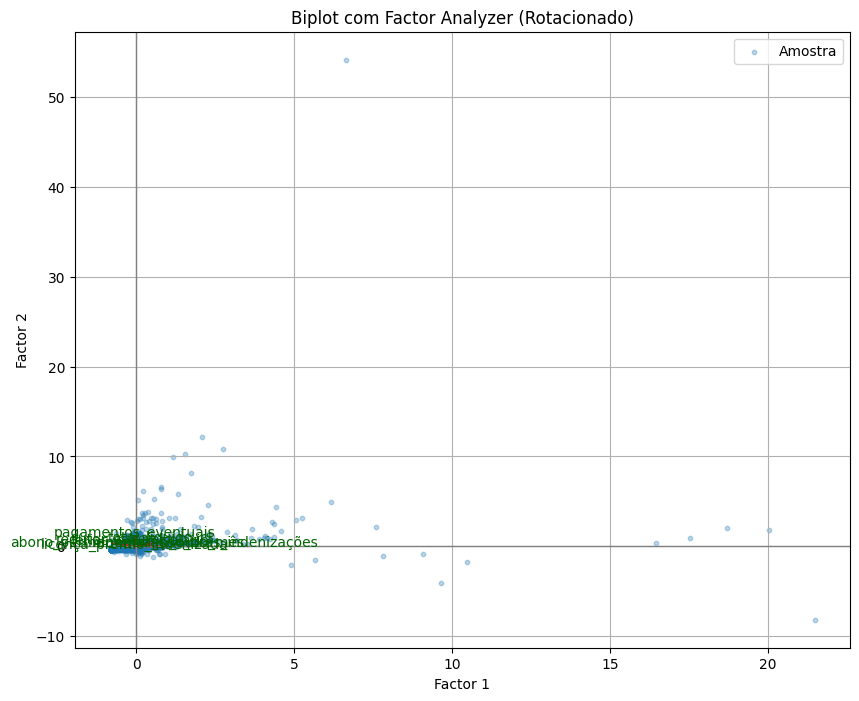

In [51]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import numpy as np

# =========================
# MODELAGEM E OBTENÇÃO DOS FATORES
# =========================

# Rotação e número de componentes
fa = FactorAnalyzer(rotation="oblimin", n_factors=3, method='principal')
fa.fit(df_scaled)

# Obter as coordenadas dos componentes principais (fatores)
factors = fa.transform(df_scaled)

# =========================
# AMOSTRAGEM (ESSENCIAL!)
# =========================

# NÃO plotar tudo (muito grande)
idx_sample = np.random.choice(len(factors), size=3000, replace=False)
factors_sample = factors[idx_sample]

# =========================
# PLOT
# =========================

plt.figure(figsize=(10, 8))

# Scatter (dados)
plt.scatter(factors_sample[:, 0], factors_sample[:, 1],
            alpha=0.3, s=10, label='Amostra')

# Vetores (variáveis)
# Certifique-se de que `loadings` também esteja definido. No contexto, ele foi definido em 'e32SQoLH_104'
# Se o kernel for reiniciado e somente este bloco for executado, `loadings` precisaria ser recalculado aqui.
# Para garantir que `loadings` esteja disponível, vamos pegá-lo diretamente do objeto `fa`.
loadings = fa.loadings_

for i in range(loadings.shape[0]):
    plt.arrow(0, 0,
              loadings[i, 0],
              loadings[i, 1],
              color='red',
              alpha=0.8,
              head_width=0.03)

    plt.text(loadings[i, 0]*1.15,
             loadings[i, 1]*1.15,
             df_scaled.columns[i],
             color='darkgreen',
             ha='center')

# Eixos centrais
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

# Labels
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title('Biplot com Factor Analyzer (Rotacionado)')
plt.legend()
plt.grid()

plt.show()

Obtendo as coordenadas das componentes rotacionadas

In [53]:
# Rotação e número de componentes
fa = FactorAnalyzer(rotation="oblimin", n_factors=3, method='principal')
fa.fit(df_scaled)

# Obter as coordenadas dos componentes principais
factors = fa.transform(df_scaled)

# Converter os resultados em um DataFrame para visualização
df_factors = pd.DataFrame(factors, columns=['Factor 1', 'Factor 2', 'Factor 3'], index=df_scaled.index)


# Exibir os dados transformados
df_factors

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor 1,Factor 2,Factor 3
0,-0.664502,-0.304271,-0.281331
1,0.085473,0.296225,0.926933
2,0.703764,-0.047811,-0.123323
3,-0.292133,-0.196713,-0.218128
4,-0.049698,-0.097985,-0.161846
...,...,...,...
494238,-0.423420,-0.228226,-0.237864
494239,-0.265896,-0.152777,-0.194504
494240,-0.093334,0.187767,0.577955
494241,0.061148,-0.160029,-0.196341


Vamos ver como os dados ficariam sem os extremos?

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


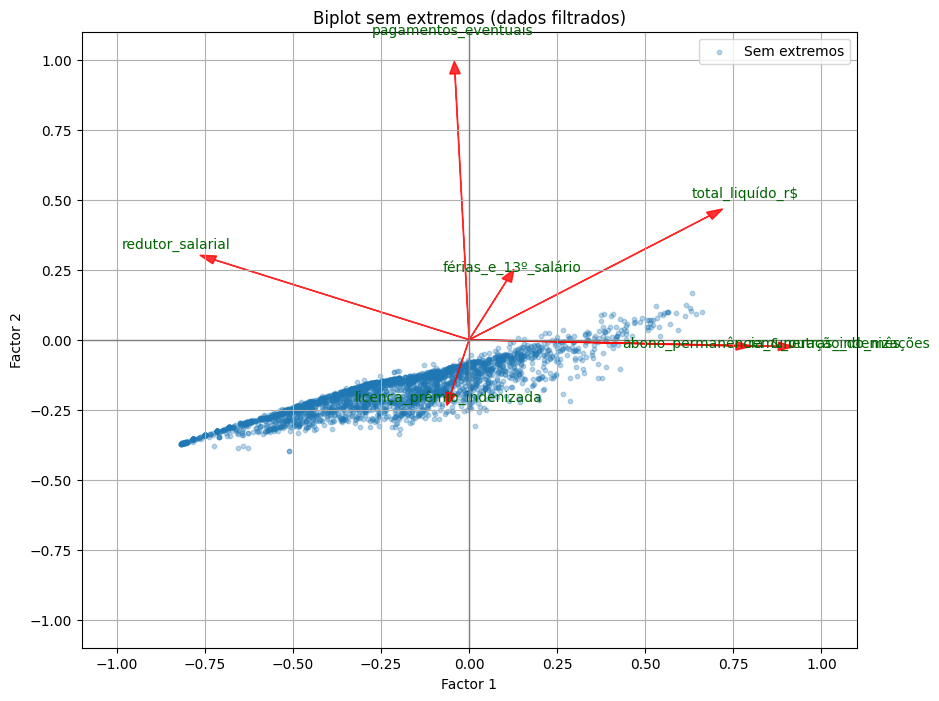

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# REMOÇÃO DE EXTREMOS (IQR)
# =========================

# mesmas features usadas no modelo
numeric_cols = df_scaled.columns

Q1 = df_scaled[numeric_cols].quantile(0.25)
Q3 = df_scaled[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df_scaled[numeric_cols] < (Q1 - 1.5 * IQR)) |
         (df_scaled[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df_sem_extremos = df_scaled[mask]

# =========================
# TRANSFORMAR NO ESPAÇO FATORIAL
# =========================

factors_sem_extremos = fa.transform(df_sem_extremos)

# =========================
# AMOSTRAGEM
# =========================

idx_sample = np.random.choice(len(factors_sem_extremos), size=3000, replace=False)
factors_sample = factors_sem_extremos[idx_sample]

# =========================
# PLOT
# =========================

plt.figure(figsize=(10, 8))

# Scatter
plt.scatter(factors_sample[:, 0], factors_sample[:, 1],
            alpha=0.3, s=10, label='Sem extremos')

# Vetores
for i in range(loadings.shape[0]):
    plt.arrow(0, 0,
              loadings[i, 0],
              loadings[i, 1],
              color='red',
              alpha=0.8,
              head_width=0.03)

    plt.text(loadings[i, 0]*1.15,
             loadings[i, 1]*1.15,
             df_scaled.columns[i],
             color='darkgreen',
             ha='center')

# Eixos
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

# Labels
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title('Biplot sem extremos (dados filtrados)')
plt.legend()
plt.grid()

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.show()

# **5. Conclusão final**

Ao comparar os resultados sem rotação e com rotação, observa-se uma diferença fundamental na forma como a estrutura dos dados é representada.

Na PCA sem rotação, os componentes principais são definidos exclusivamente pela maximização da variância. Como consequência, as variáveis com maior variabilidade — neste caso, aquelas associadas aos maiores valores de remuneração — tendem a dominar os primeiros componentes. Isso explica a forte concentração de carga em poucas variáveis, refletindo a estrutura de variância do sistema.

Por outro lado, ao aplicar a rotação, ocorre uma redistribuição das cargas fatoriais entre os componentes. Essa transformação não altera os dados nem a variância total explicada, mas reorganiza os eixos de forma a tornar a interpretação mais clara. O resultado é a emergência de uma estrutura mais interpretável, na qual diferentes dimensões do sistema — como salário base, pagamentos eventuais e ajustes — passam a ser representadas de forma mais separada.

Dessa forma, enquanto a PCA sem rotação evidencia onde está concentrada a variância dos dados, a versão rotacionada revela como essa variância está estruturada internamente.

Essa distinção é fundamental: a primeira abordagem é mais adequada para compreender a distribuição da variabilidade, enquanto a segunda facilita a interpretação dos fenômenos subjacentes.


**Para lembrar:**

- “A variância mostra o que importa…”

- “A estrutura mostra o que está acontecendo.”